# Finite-size ResNet clustering conductance

This notebook repeats the raw, non-spin-inverted ResNet analysis for $L=16,32,64,128$ and tests the finite-size form $\phi(L) \propto L^{-\alpha}$ for **standard cluster conductance**. It expects the detached simulations in `data/raw/finite_size/L<L>` to be complete.

Conductance is computed on the 31,000 seed–temperature mean embeddings for each lattice size:

$$\phi(C)=\frac{\sum_{i\in C,j\notin C}w_{ij}}{\min(\mathrm{vol}(C),\mathrm{vol}(\bar C))}.$$

The three sizes provide only an initial exponent estimate, not a reliable asymptotic scaling claim.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import linregress
from sklearn.cluster import MiniBatchKMeans
from torchvision.models import ResNet18_Weights, resnet18

SIZES = (16, 32, 64, 128)
N_RUNS = 1_000
N_TEMPERATURES = 31
BINS_PER_TEMPERATURE = 10
N_CLUSTERS = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / "data" / "raw").exists())
RAW_ROOT = Path.home() / "senior-thesis" / "data" / "raw" / "finite_size"
L16_ROOT = Path.home() / "scratch" / "senior thesis"
OUTPUT_ROOT = REPO_ROOT / "data" / "processed" / "finite_size"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

temperatures = np.array([1.50, 1.60, 1.70, 1.80, 1.90, 2.00, 2.05, 2.10, 2.15, 2.18, 2.20, 2.22, 2.24, 2.25, 2.26, 2.27, 2.28, 2.29, 2.30, 2.32, 2.34, 2.36, 2.38, 2.40, 2.45, 2.50, 2.60, 2.70, 2.80, 2.90, 3.00])
print(f"Device: {DEVICE}")

Device: cuda


## Frozen ResNet-18 embeddings

Every $L\times L$ spin configuration is resized and normalized with the pretrained ImageNet weights. The model is frozen; only embeddings are extracted. Results are cached separately for each lattice size.

In [2]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.fc = torch.nn.Identity()
model.eval().to(DEVICE)
mean = torch.tensor(weights.transforms().mean, device=DEVICE).view(1, 3, 1, 1)
std = torch.tensor(weights.transforms().std, device=DEVICE).view(1, 3, 1, 1)

def sorted_runs(size):
    root = RAW_ROOT / f"L{size}"
    runs = sorted(root.glob(f"ising{size}_tc_[0-9]*"), key=lambda p: int(p.name.rsplit("_", 1)[1]))
    assert len(runs) == N_RUNS, f"L={size}: found {len(runs)} of {N_RUNS} runs"
    return runs

def embed_size(size, batch_size=512):
    cache = OUTPUT_ROOT / f"ising{size}_resnet18_raw_seed_temperature_means.npz"
    if cache.exists():
        return dict(np.load(cache))

    if size == 16:
        full_embeddings = np.load(
            L16_ROOT / "data/processed/ising16_resnet18_raw_embeddings.npy",
            mmap_mode="r",
        )
        full_m = np.load(
            L16_ROOT / "data/processed/ising16_resnet18_raw_signed_magnetization.npy"
        )
        seed_temperature_embeddings = np.asarray(full_embeddings).reshape(
            N_RUNS, N_TEMPERATURES, BINS_PER_TEMPERATURE, 512
        ).mean(axis=2)
        seed_temperature_m = full_m.reshape(
            N_RUNS, N_TEMPERATURES, BINS_PER_TEMPERATURE
        ).mean(axis=2)
        np.savez(
            cache, embeddings=seed_temperature_embeddings,
            signed_m=seed_temperature_m, temperatures=temperatures,
        )
        return {
            "embeddings": seed_temperature_embeddings,
            "signed_m": seed_temperature_m,
            "temperatures": temperatures,
        }

    seed_temperature_embeddings = np.empty((N_RUNS, N_TEMPERATURES, 512), np.float32)
    seed_temperature_m = np.empty((N_RUNS, N_TEMPERATURES), np.float32)

    with torch.inference_mode():
        for run_index, run_dir in enumerate(sorted_runs(size)):
            name = run_dir.name
            spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8).reshape(-1, size, size)
            assert spins.shape == (N_TEMPERATURES * BINS_PER_TEMPERATURE, size, size)
            run_embeddings = []
            for start in range(0, len(spins), batch_size):
                batch = torch.from_numpy(spins[start:start + batch_size].astype(np.float32)).to(DEVICE)
                batch = (batch + 1.0) / 2.0
                batch = batch[:, None].repeat(1, 3, 1, 1)
                batch = torch.nn.functional.interpolate(batch, size=(224, 224), mode="nearest")
                batch = (batch - mean) / std
                run_embeddings.append(model(batch).cpu().numpy())
            run_embeddings = np.concatenate(run_embeddings).reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, 512)
            seed_temperature_embeddings[run_index] = run_embeddings.mean(axis=1)
            seed_temperature_m[run_index] = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, -1).mean(axis=(1, 2))
            if (run_index + 1) % 100 == 0:
                print(f"L={size}: embedded {run_index + 1}/{N_RUNS} seeds")

    np.savez(cache, embeddings=seed_temperature_embeddings, signed_m=seed_temperature_m, temperatures=temperatures)
    return {"embeddings": seed_temperature_embeddings, "signed_m": seed_temperature_m, "temperatures": temperatures}

datasets = {size: embed_size(size) for size in SIZES}

## Unsupervised clusters and conventional conductance

K-means is fitted independently at each size. Cluster numbers are then reordered only for presentation by their mean signed magnetization. Dense RBF affinities are accumulated in GPU-sized row batches, so no nearest-neighbor approximation is used.

In [3]:
def dense_conductance(features, labels, batch_size=512, random_state=42):
    features = np.asarray(features, np.float32)
    labels = np.asarray(labels, np.int64)
    rng = np.random.default_rng(random_state)
    left = rng.integers(0, len(features), 200_000)
    right = rng.integers(0, len(features), 200_000)
    d2_sample = np.sum((features[left] - features[right]) ** 2, axis=1)
    sigma2 = float(np.median(d2_sample[d2_sample > 0]))

    x = torch.from_numpy(features).to(DEVICE)
    y = torch.from_numpy(labels).to(DEVICE)
    norms = (x ** 2).sum(dim=1).view(1, -1)
    volume = np.zeros(N_CLUSTERS, np.float64)
    cut = np.zeros(N_CLUSTERS, np.float64)
    total_volume = 0.0

    with torch.inference_mode():
        for start in range(0, len(features), batch_size):
            stop = min(start + batch_size, len(features))
            batch = x[start:stop]
            d2 = ((batch ** 2).sum(1, keepdim=True) + norms - 2 * batch @ x.T).clamp_min_(0)
            affinity = torch.exp(-d2 / (2 * sigma2))
            affinity[torch.arange(stop - start, device=DEVICE), torch.arange(start, stop, device=DEVICE)] = 0
            row_volume = affinity.sum(1)
            total_volume += float(row_volume.sum().cpu())
            for cluster in range(N_CLUSTERS):
                rows = y[start:stop] == cluster
                if torch.any(rows):
                    volume[cluster] += float(row_volume[rows].sum().cpu())
                    cut[cluster] += float(affinity[rows][:, y != cluster].sum().cpu())

    return np.array([
        cut[c] / min(volume[c], total_volume - volume[c]) for c in range(N_CLUSTERS)
    ]), sigma2

conductance_rows = []
population_rows = []
for size, data in datasets.items():
    features = data["embeddings"].reshape(-1, 512)
    signed_m = data["signed_m"].reshape(-1)
    model_km = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=42, batch_size=4096, n_init=20)
    raw_labels = model_km.fit_predict(features)
    raw_order = np.argsort([signed_m[raw_labels == c].mean() for c in range(N_CLUSTERS)])
    remap = np.empty(N_CLUSTERS, int)
    remap[raw_order] = np.arange(N_CLUSTERS)
    labels = remap[raw_labels]
    phi, sigma2 = dense_conductance(features, labels)
    for cluster, value in enumerate(phi):
        conductance_rows.append({"L": size, "cluster": cluster, "conductance": value, "sigma_squared": sigma2})
    tiled_t = np.tile(temperatures, N_RUNS)
    for temperature in temperatures:
        at_t = labels[tiled_t == temperature]
        for cluster in range(N_CLUSTERS):
            population_rows.append({"L": size, "temperature": temperature, "cluster": cluster, "fraction": np.mean(at_t == cluster)})

conductance = pd.DataFrame(conductance_rows)
populations = pd.DataFrame(population_rows)
conductance.to_csv(OUTPUT_ROOT / "resnet18_dense_cluster_conductance_by_size.csv", index=False)
populations.to_csv(OUTPUT_ROOT / "resnet18_cluster_populations_by_size.csv", index=False)
conductance

,L,cluster,conductance,sigma_squared
0,16,0,0.617255,47.155979
1,16,1,0.483906,47.155979
2,16,2,0.508414,47.155979
3,32,0,0.437599,53.943314
4,32,1,0.432890,53.943314
5,32,2,0.537723,53.943314
6,64,0,0.457885,65.435295
7,64,1,0.650282,65.435295
8,64,2,0.435619,65.435295
9,128,0,0.602996,61.063950


## Initial finite-size power-law fits

The log–log fit uses only three sizes. Report the slope and $R^2$, but treat the exponent as exploratory until additional sizes and uncertainty estimates are available.

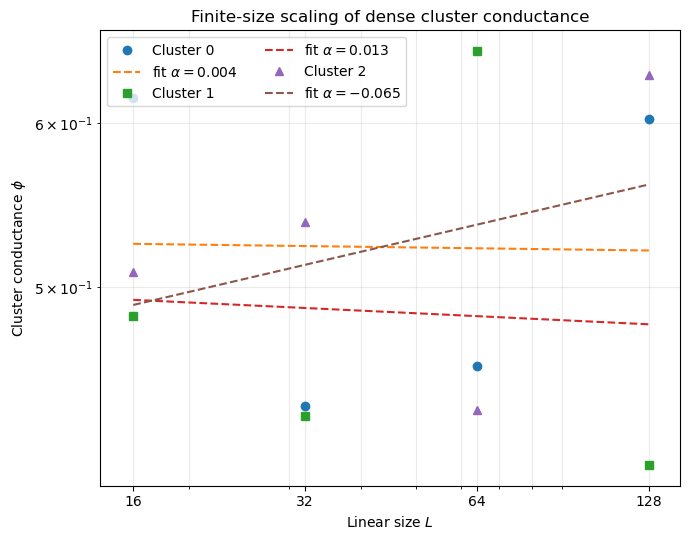

,cluster,alpha,intercept,r_squared,slope_stderr
0,0,0.003579,-0.635334,0.000317,0.142194
1,1,0.013116,-0.671322,0.003249,0.162445
2,2,-0.064611,-0.892527,0.140199,0.113140


In [4]:
fit_rows = []
fig, ax = plt.subplots(figsize=(7, 5.5))
markers = ("o", "s", "^")
for cluster in range(N_CLUSTERS):
    data = conductance[conductance.cluster == cluster].sort_values("L")
    fit = linregress(np.log(data.L), np.log(data.conductance))
    alpha = -fit.slope
    fit_rows.append({"cluster": cluster, "alpha": alpha, "intercept": fit.intercept, "r_squared": fit.rvalue ** 2, "slope_stderr": fit.stderr})
    ax.loglog(data.L, data.conductance, marker=markers[cluster], linestyle="none", label=f"Cluster {cluster}")
    grid = np.geomspace(min(SIZES), max(SIZES), 100)
    ax.loglog(grid, np.exp(fit.intercept) * grid ** fit.slope, linestyle="--", label=fr"fit $\alpha={alpha:.3f}$")

ax.set(xlabel="Linear size $L$", ylabel="Cluster conductance $\phi$", title="Finite-size scaling of dense cluster conductance")
ax.set_xticks(SIZES, labels=[str(size) for size in SIZES])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlim(14, 145)
ax.grid(True, which="both", alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "resnet18_conductance_power_law.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

fits = pd.DataFrame(fit_rows)
fits.to_csv(OUTPUT_ROOT / "resnet18_conductance_power_law_fits.csv", index=False)
fits

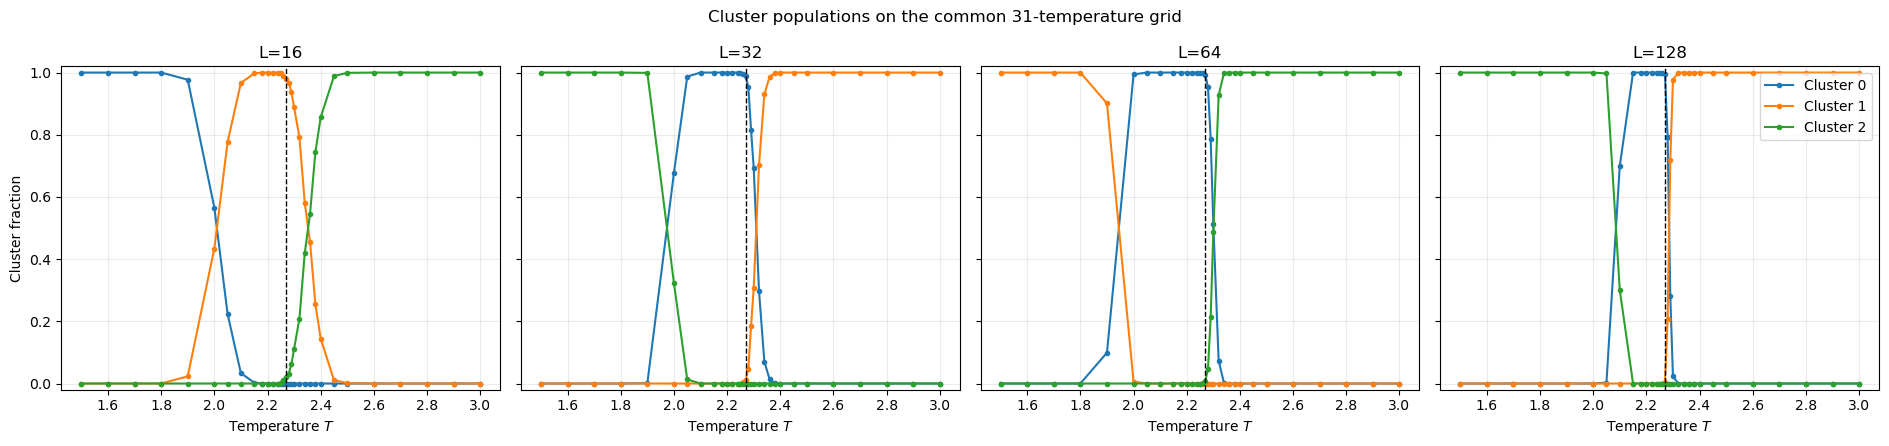

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5), sharex=True, sharey=True)
for axis, size in zip(axes, SIZES):
    subset = populations[populations.L == size]
    for cluster in range(N_CLUSTERS):
        data = subset[subset.cluster == cluster]
        axis.plot(data.temperature, data.fraction, "o-", markersize=3, label=f"Cluster {cluster}")
    axis.axvline(2 / np.log(1 + np.sqrt(2)), color="black", linestyle="--", linewidth=1)
    axis.set(title=f"L={size}", xlabel="Temperature $T$", ylim=(-0.02, 1.02))
    axis.grid(alpha=0.25)
axes[0].set_ylabel("Cluster fraction")
axes[-1].legend()
fig.suptitle("Cluster populations on the common 31-temperature grid")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "resnet18_cluster_populations_by_size.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

## Interpretation

No cluster shows credible conductance power-law scaling over $L=16$–128. The fitted exponents are $0.004$, $0.013$, and $-0.065$, with $R^2$ values below 0.15 and slope uncertainties larger than the exponents. The conductance values also vary nonmonotonically with size.

Therefore this global frozen-ResNet/K-means conductance should not be used to estimate $T_c$ or a critical exponent. The Binder crossings, susceptibility shifts, and thermodynamic finite-size powers in the companion notebook provide substantially cleaner scaling observables.